In [1]:
# Set up SAM2 for segmentation

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator
from sam2.sam2_image_predictor import SAM2ImagePredictor # initially used SAM2AutomaticMaskGenerator, but was too slow

device = torch.device("mps")

CHECKPOINT = "checkpoints/sam2_hiera_large.pt"
MODEL_CFG = "configs/sam2/sam2_hiera_l.yaml"

sam2_model = build_sam2(MODEL_CFG, CHECKPOINT, device=device)

predictor = SAM2ImagePredictor(sam2_model)
print("Predictor loaded!")

Predictor loaded!


In [2]:
def segment(image_path, output_path=None):
    """
    Take in an image, run SAM2, and return best person mask
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    image_array = np.array(image)

    # Get masks
    l, w = image_array.shape[:2] # length, width
    input_pts = np.array([
        [w // 2, l // 2], # center of photo 
        [w // 2, 2 * l // 5], # upper body 
        [w // 2, 4 * l // 5], # lower body 
        [w // 3, l // 2], # left side of body 
        [2 * w // 3, l // 2], # right side of body 
        [2, 2], # top-left corner, background 
        [w - 2, l - 2], # bottom-right corner, background 
        [2, l - 2], # bottom-left corner, background 
        [w - 2, 2] # top-right corner, background 
    ])
    labels = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0]) # last four input points are background
    predictor.set_image(image_array)
    masks_raw, scores, low_res_masks_logits = predictor.predict(point_coords=input_pts, point_labels=labels)
    masks = [{'segmentation': masks_raw[i].astype(bool), 'area': masks_raw[i].sum()} for i in range(len(masks_raw))]

    # Sort by mask area
    masks = sorted(masks, key=lambda m: m['area'], reverse=True)

    # Select mask that most likely matches the human figure
    # (i.e. large area but not the largest [would likely be the entire background])
    area = image_array.shape[0] * image_array.shape[1] # height * width
    silhouette_mask = None

    for mask in masks:
        coverage = mask['area'] / area
        if coverage < 0.70 : # max out at 70% coverage bc don't want background; want biggest area otherwise; masks already sorted by area
            silhouette_mask = mask
            break
    if silhouette_mask is None: # take largest area otherwise 
        silhouette_mask = masks[0]

    silhouette = silhouette_mask['segmentation']

    # fill holes
    silhouette_uint8 = silhouette.astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (10, 10)) # make a kernel in ellipse size (humans not boxy) to pass over
    silhouette_uint8 = cv2.morphologyEx(silhouette_uint8, cv2.MORPH_CLOSE, k)

    # get rid of small background noise 
    n_blobs, labels, stats, coords = cv2.connectedComponentsWithStats(silhouette_uint8)
    block_areas = stats[1:, cv2.CC_STAT_AREA] # get array of areas for every block (excl. background)
    biggest_label = 1 + np.argmax(block_areas) # select idx of largest area (silhouette)
    silhouette_uint8 = np.where(labels == biggest_label, 255, 0).astype(np.uint8) # if label belongs to silhouette, set to 255
    silhouette = silhouette_uint8.astype(bool)
    
    # Put mask over image
    masked_img = image_array.copy()
    masked_img[~silhouette] = 0  # black out background

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_array)
    axes[0].set_title("Original")
    axes[0].axis('off')

    axes[1].imshow(silhouette, cmap='gray')
    axes[1].set_title("Raw Mask")
    axes[1].axis('off')

    axes[2].imshow(masked_img)
    axes[2].set_title("Human Silhouette")
    axes[2].axis('off')

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path)
    plt.show()

    return silhouette, masked_img

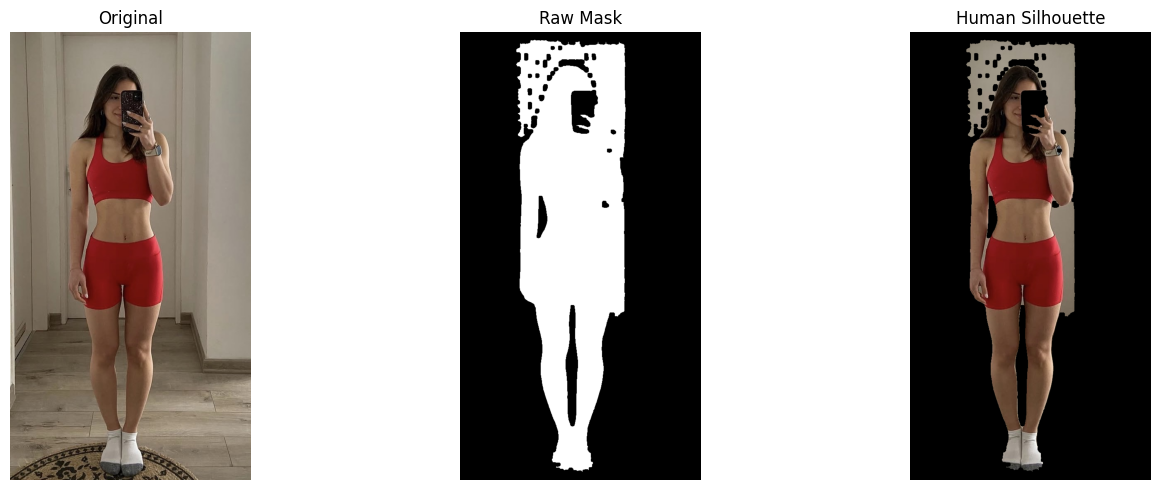

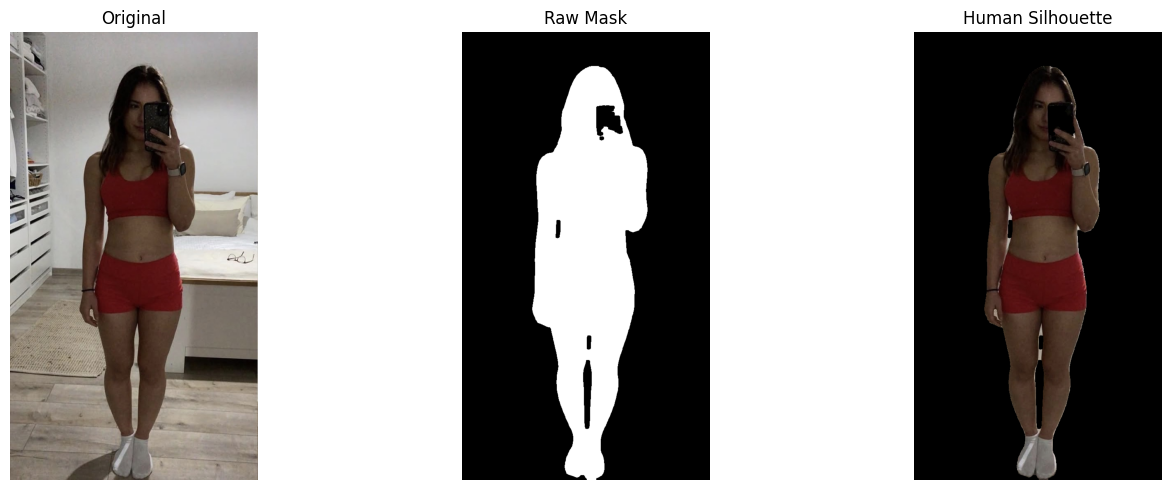

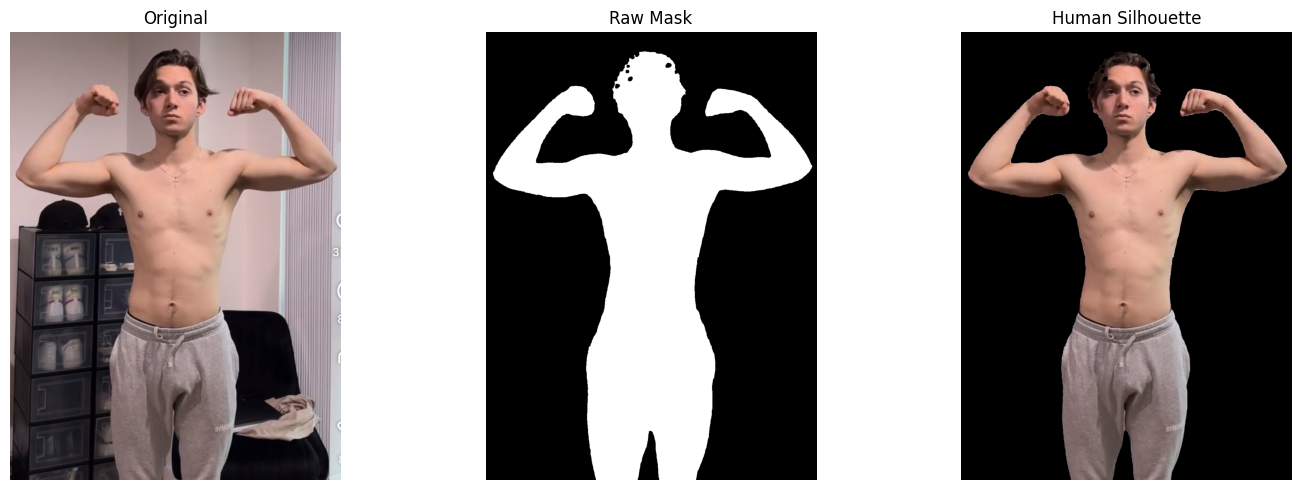

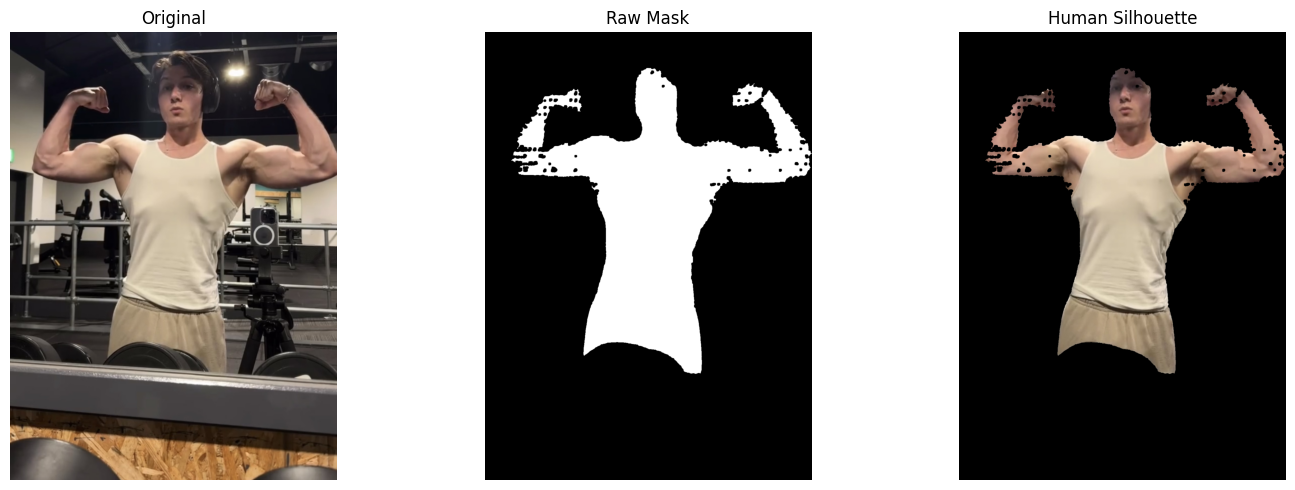

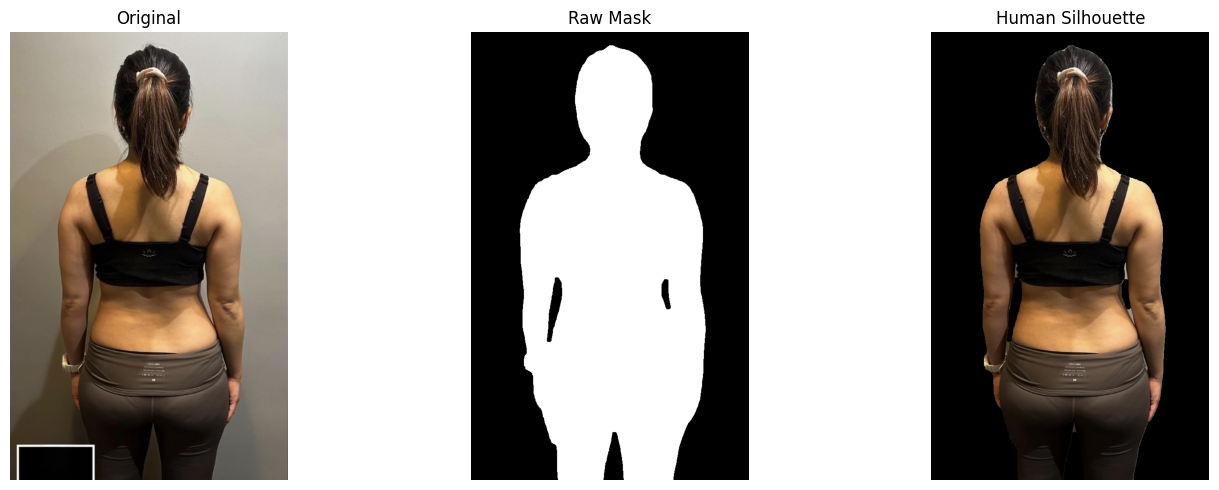

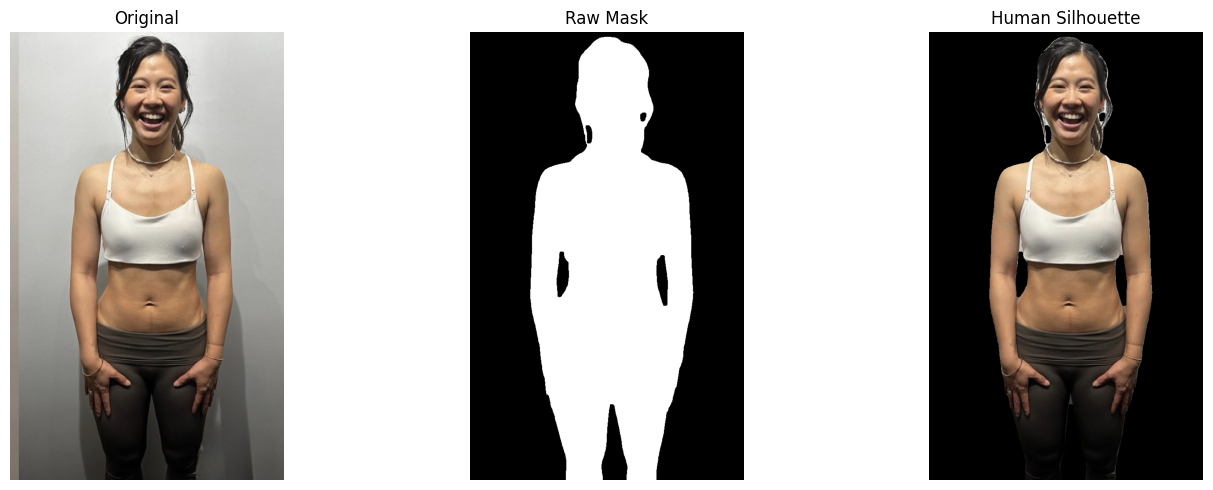

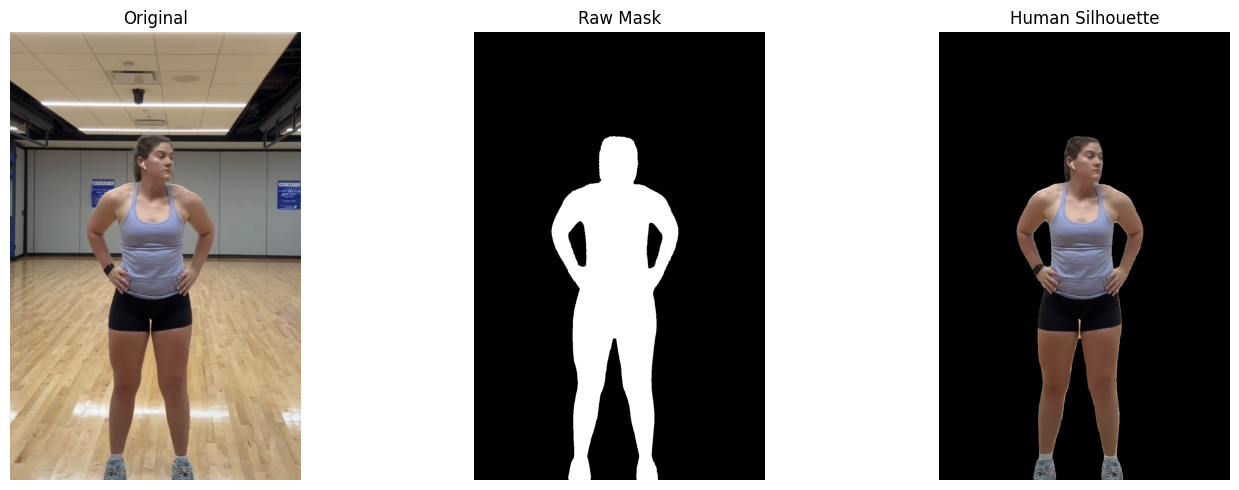

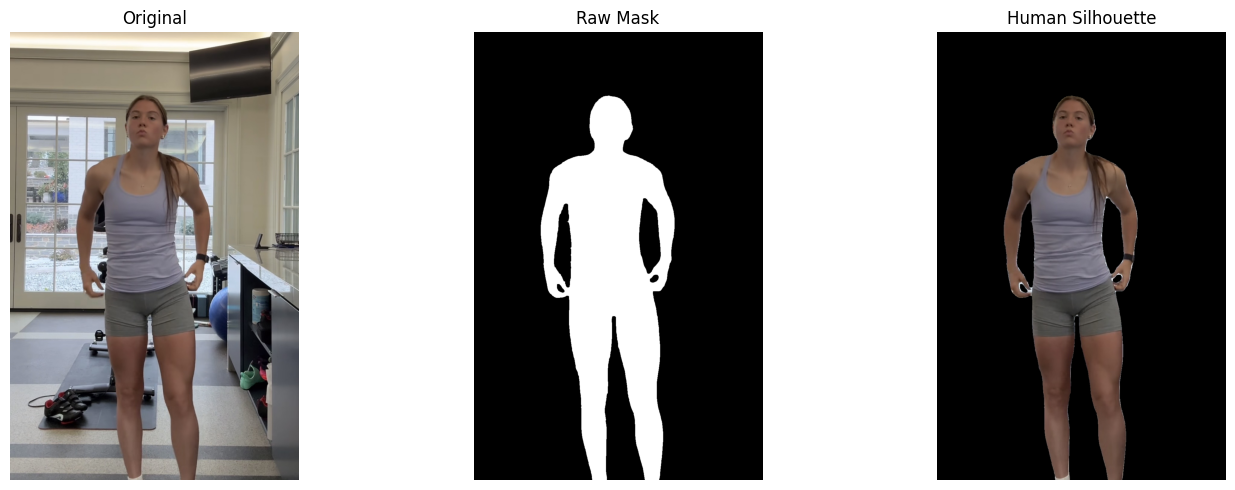

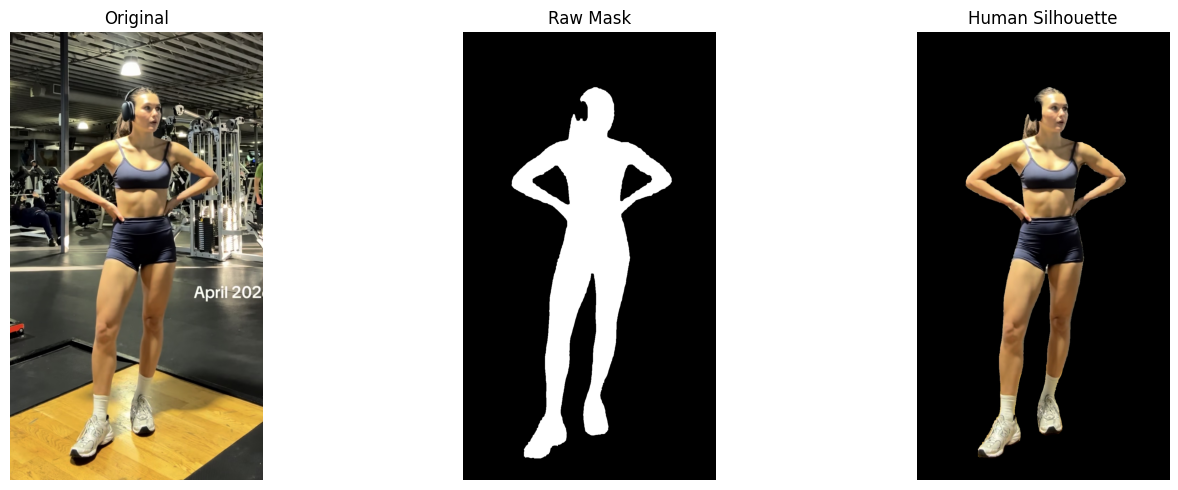

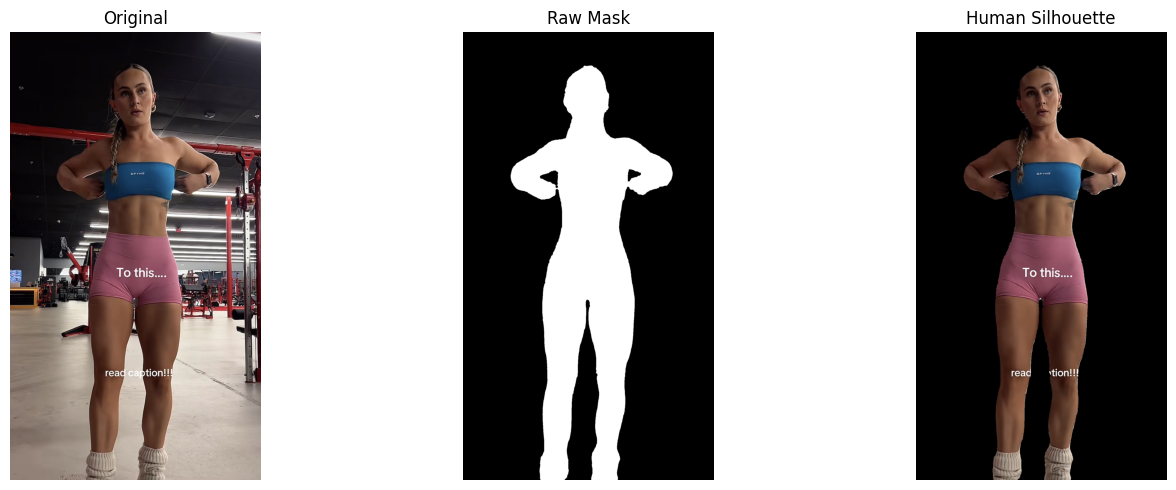

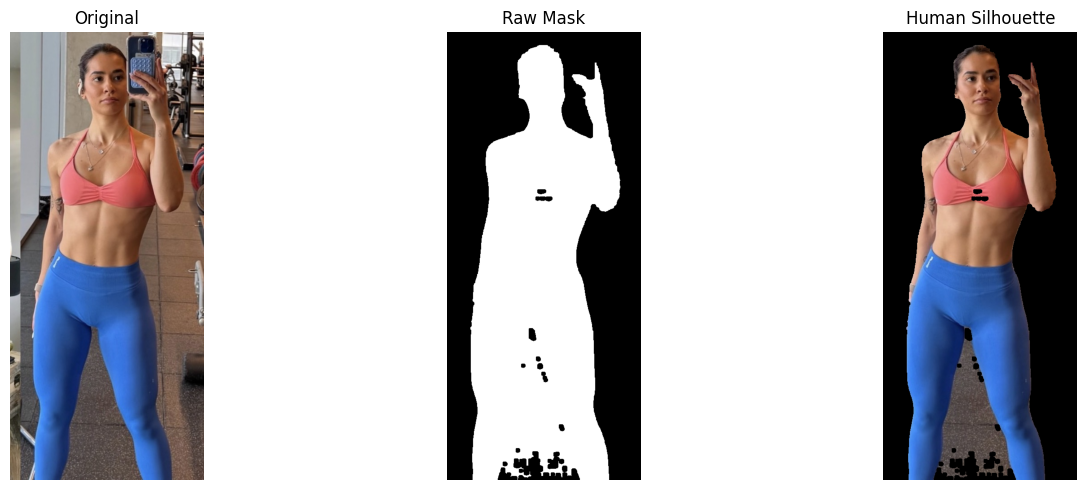

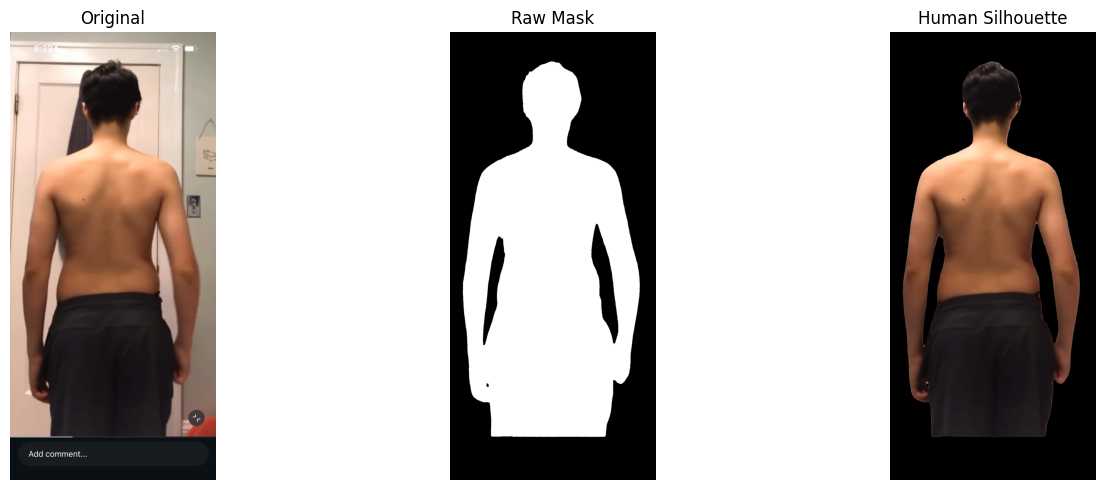

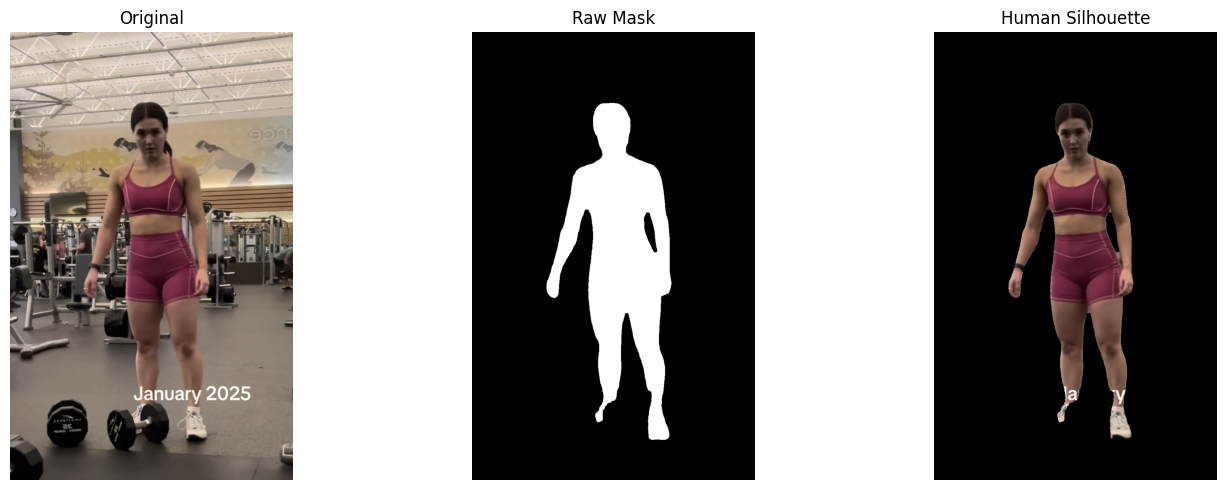

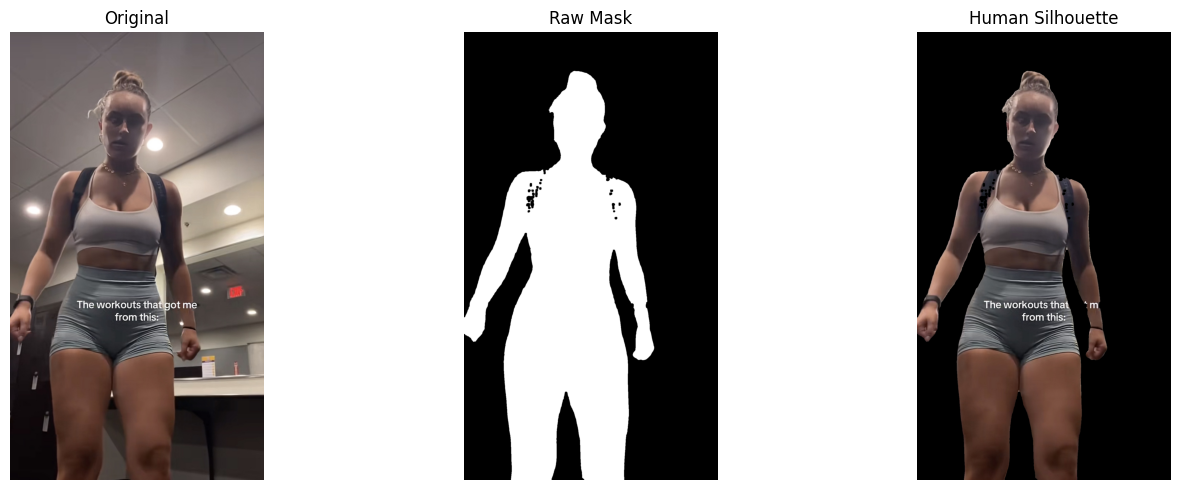

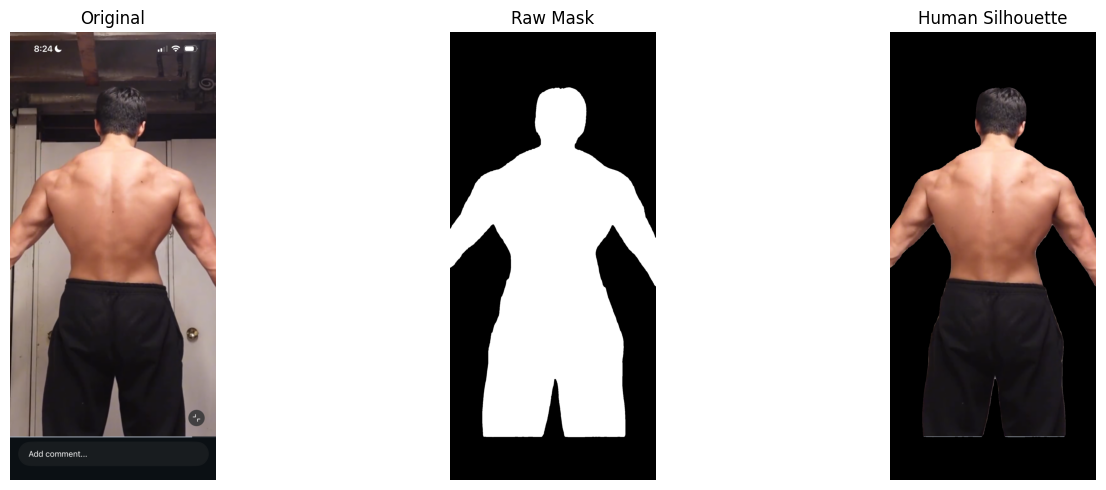

In [ ]:
# apply segment() to all photos

from pathlib import Path 

folder_path = Path("/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/og_photos")
for img_path in folder_path.glob("*.jpg"):
    segment(img_path, Path(f"/Users/hannahlatif/Documents/CS131/Final_Project/Milestone/segmented/{img_path.stem}_segmented{img_path.suffix}"))


Pose Keypoint Detection via MediaPipe BlazePose

In [5]:
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
print("BlazePose loaded")

BlazePose loaded


In [ ]:
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python.vision import PoseLandmarker, PoseLandmarkerOptions
import mediapipe as mp

options = PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path="checkpoints/pose_landmarker.task"),
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1
)

pose_landmarker = PoseLandmarker.create_from_options(options)
print("Pose landmarker loaded")

I0000 00:00:1779770062.262500 31431008 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
I0000 00:00:1779770062.393243 31431008 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Pose landmarker loaded!


W0000 00:00:1779770062.471817 31431014 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779770062.609536 31431015 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [16]:
def detect_pose(image_path):
    """
    Detect key body points an image via MediaPipe BlazePose, 
    returning coordinates and an annotated version of the image. 
    """
    # Load image
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    # Make image MediaPipe-friendly
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_np)

    # Pose detection
    pose = pose_landmarker.detect(mp_image)

    if not pose.pose_landmarks:
        print(f"No person found in {image_path}")
        return None, image_np

    # Get (x, y) pixel coordinates of each landmark
    h, w = image_np.shape[:2]
    figure = pose.pose_landmarks[0]  
    keypoints = { # convert normalized dimensions to coordinates
        'nose': (int(figure[0].x * w),  int(figure[0].y * h)),
        'left shoulder': (int(figure[11].x * w), int(figure[11].y * h)),
        'right shoulder': (int(figure[12].x * w), int(figure[12].y * h)),
        'left elbow': (int(figure[13].x * w), int(figure[13].y * h)),
        'right elbow': (int(figure[14].x * w), int(figure[14].y * h)),
        'left hip': (int(figure[23].x * w), int(figure[23].y * h)),
        'right hip': (int(figure[24].x * w), int(figure[24].y * h)),
        'left knee': (int(figure[25].x * w), int(figure[25].y * h)),
        'right knee': (int(figure[26].x * w), int(figure[26].y * h))}

    # Annotate image
    annotated = image_np.copy()
    for name, (x, y) in keypoints.items():
        cv2.circle(annotated, (x, y), 9, (0, 0, 255), -1) # filled circle at each keypoint
        cv2.putText(annotated, name, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image_np); axes[0].set_title("OG"); axes[0].axis('off')
    axes[1].imshow(annotated); axes[1].set_title("With Keypoints"); axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    return keypoints, annotated


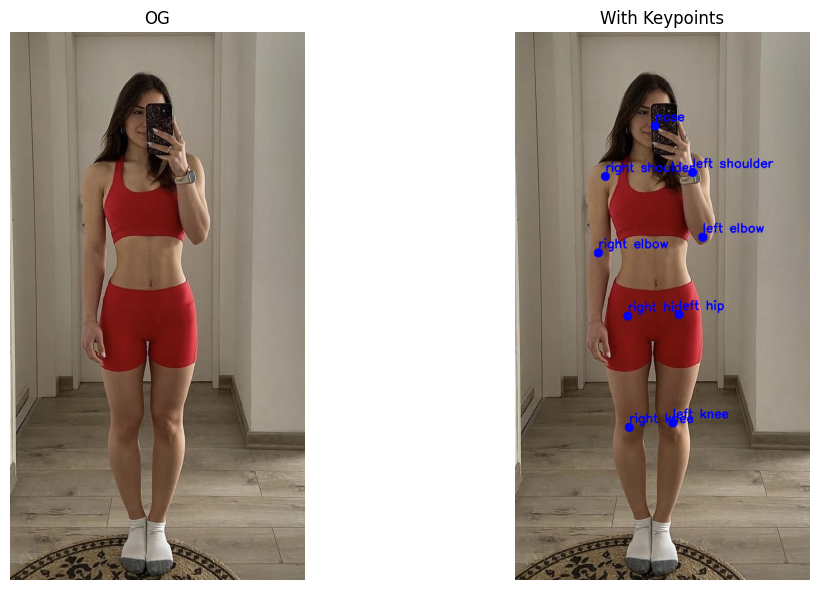

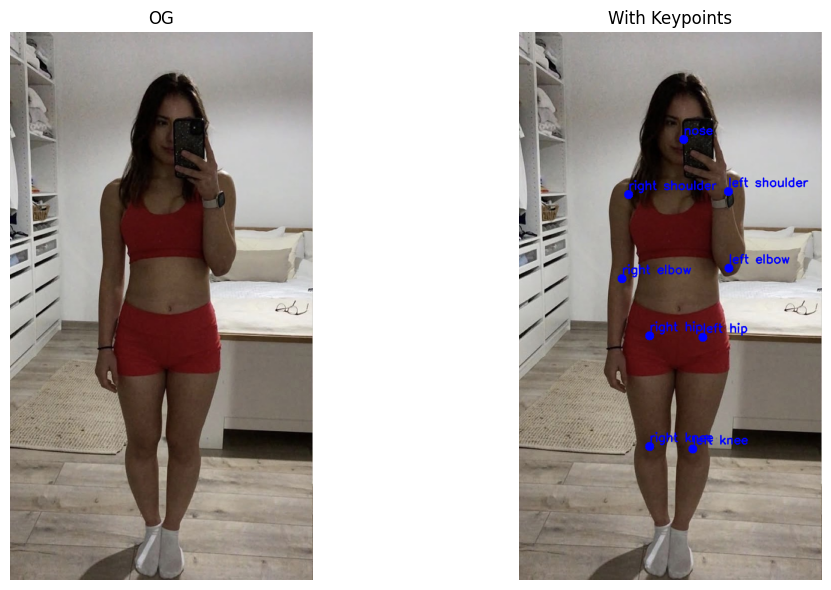

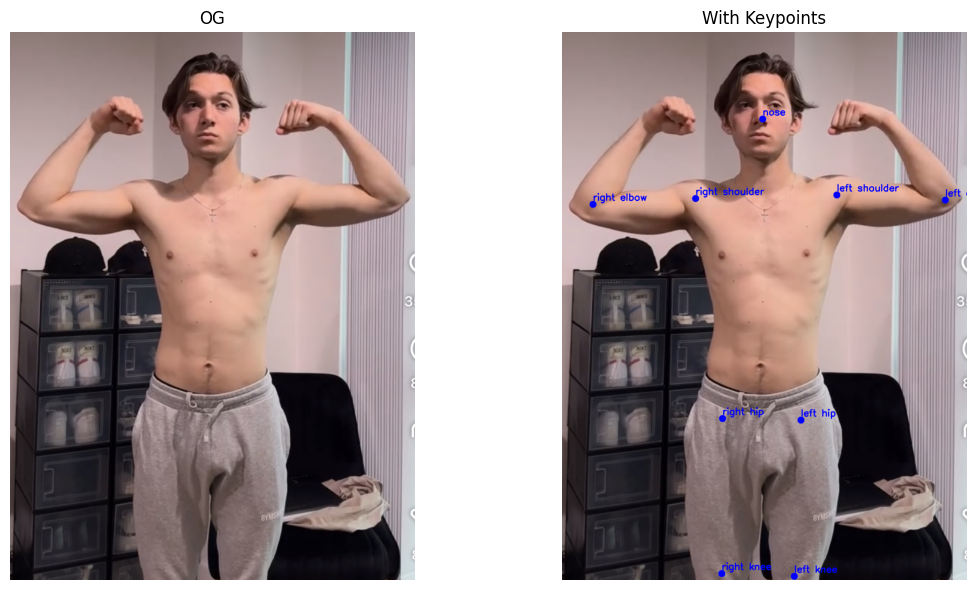

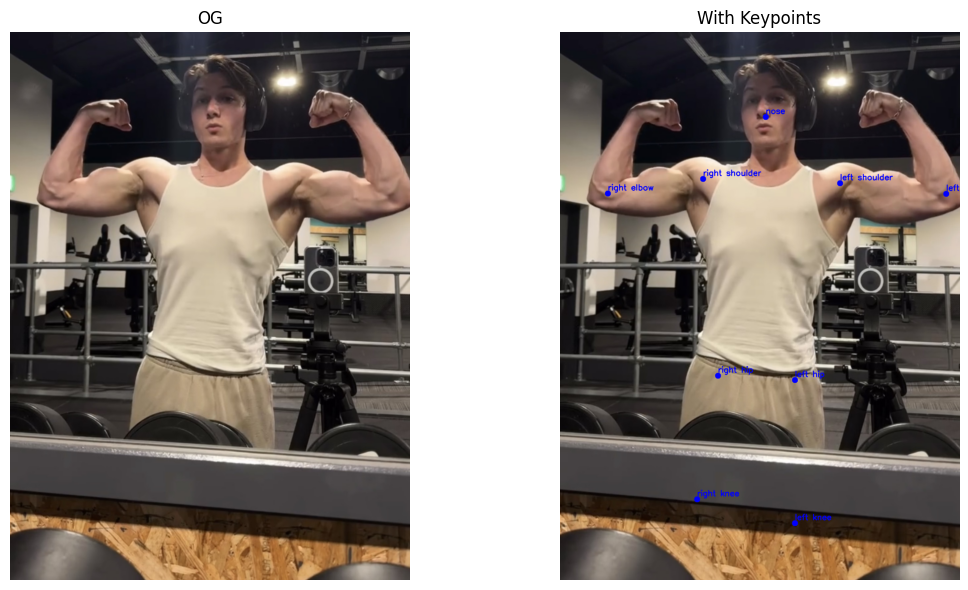

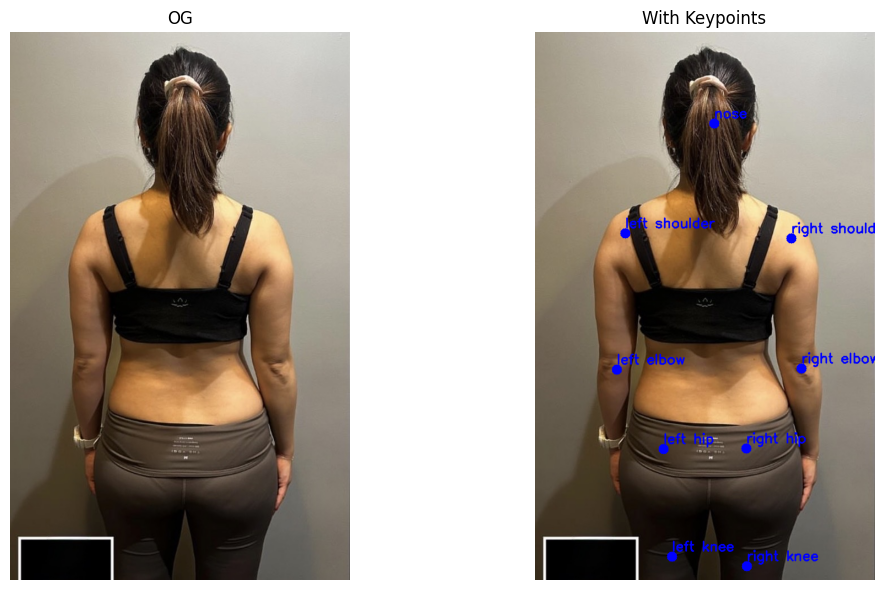

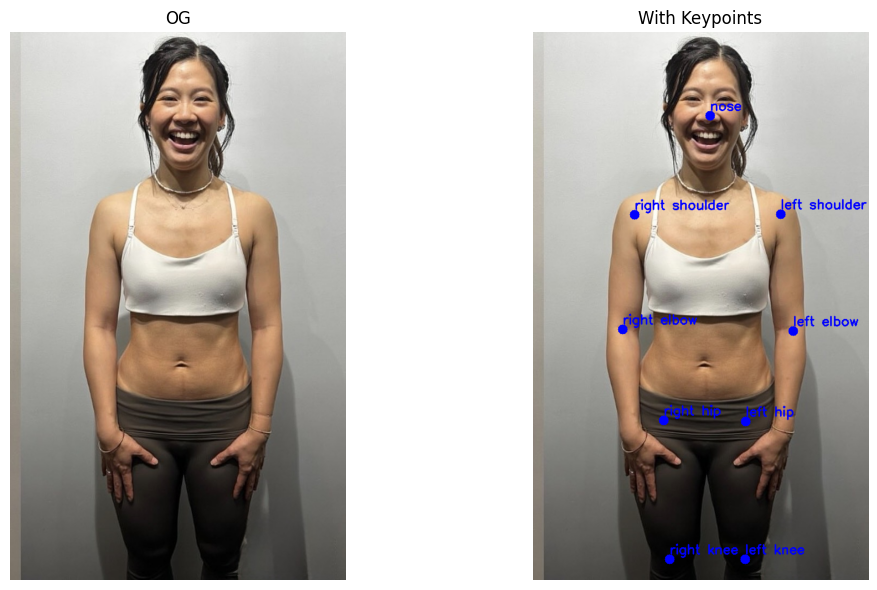

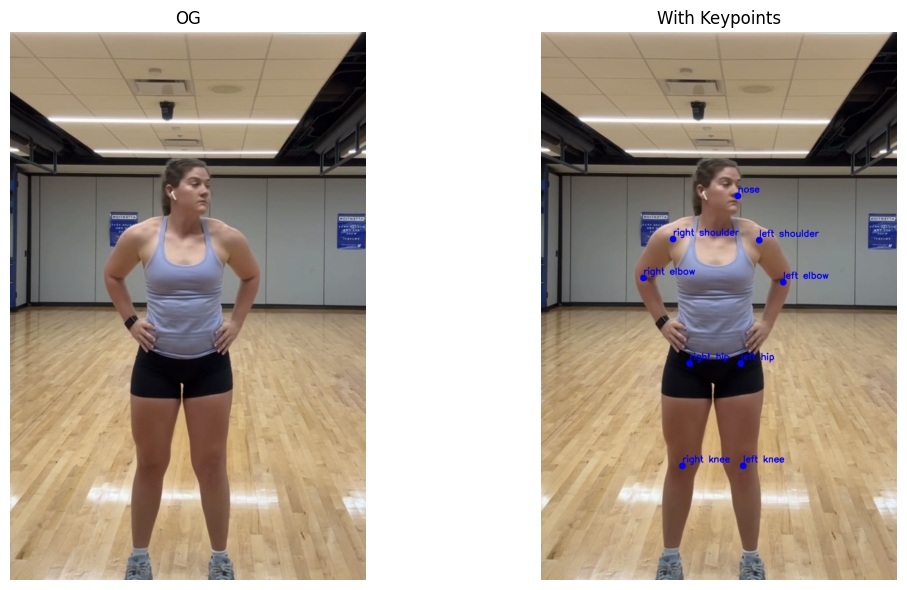

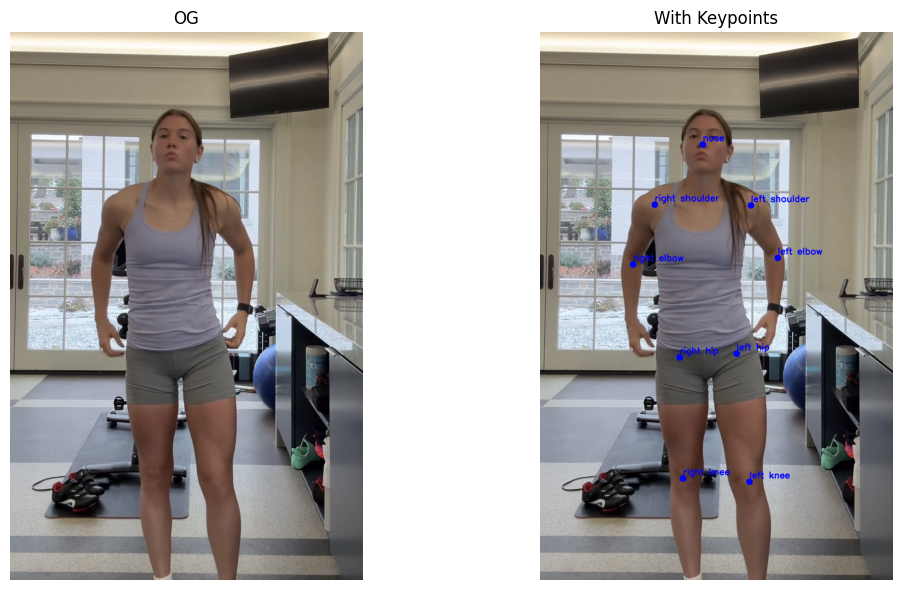

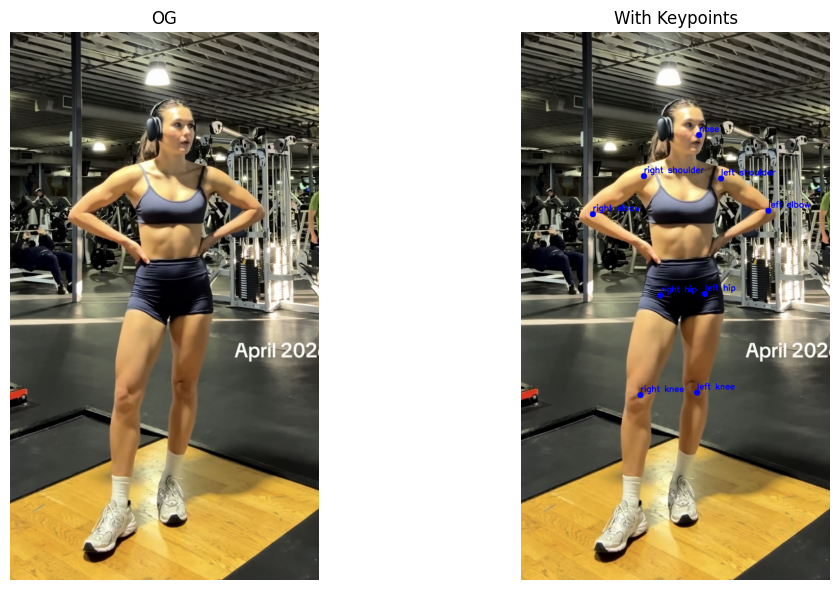

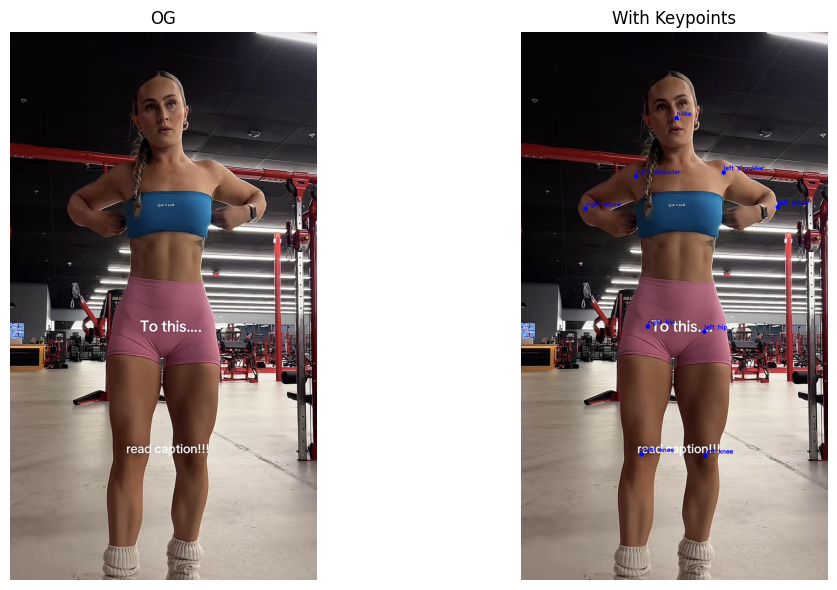

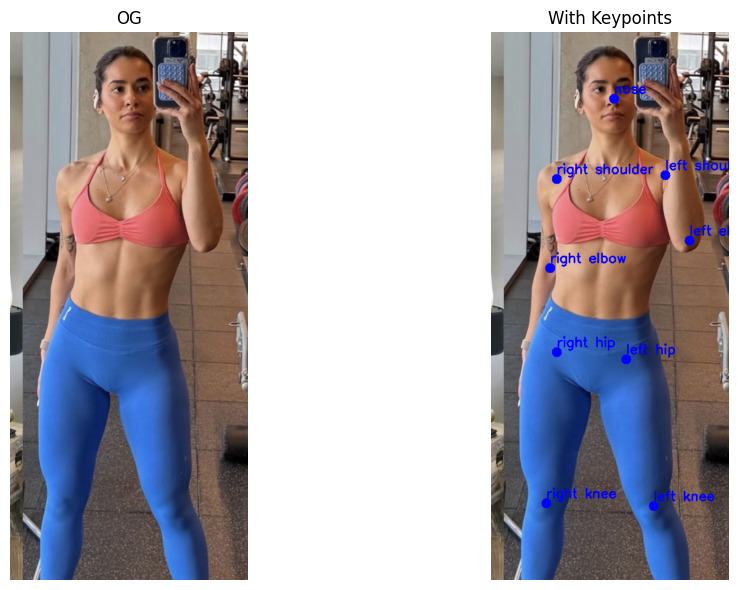

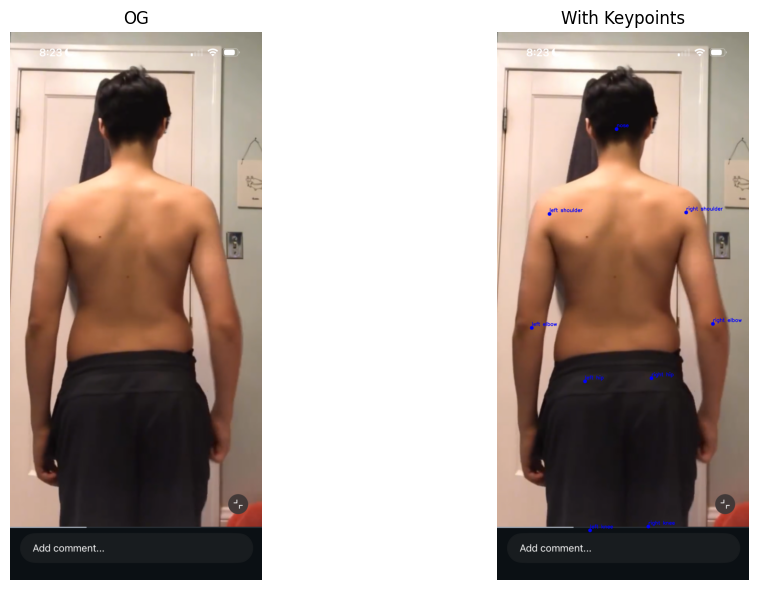

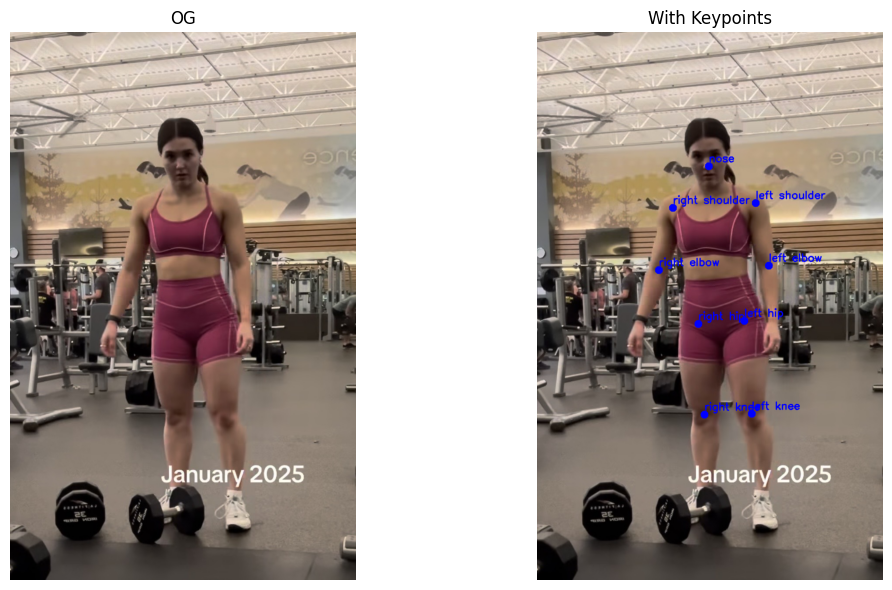

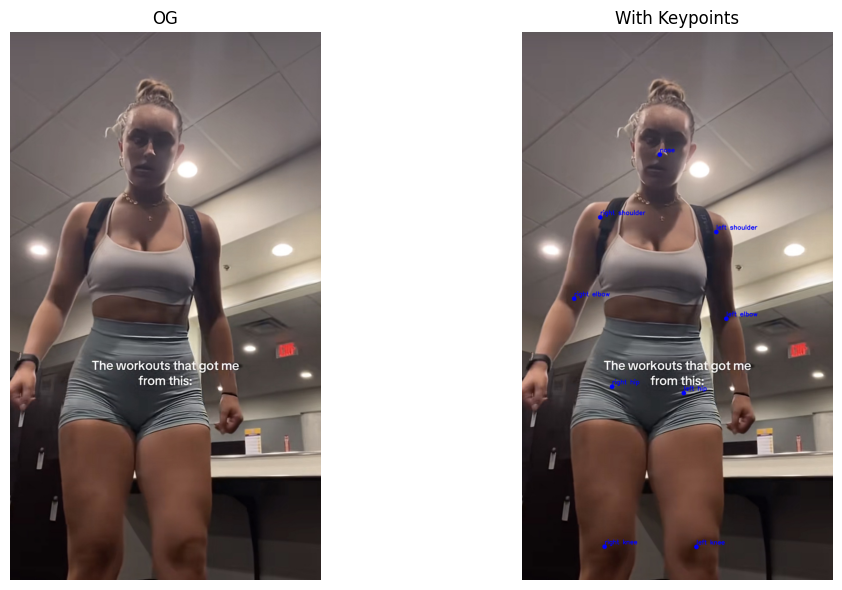

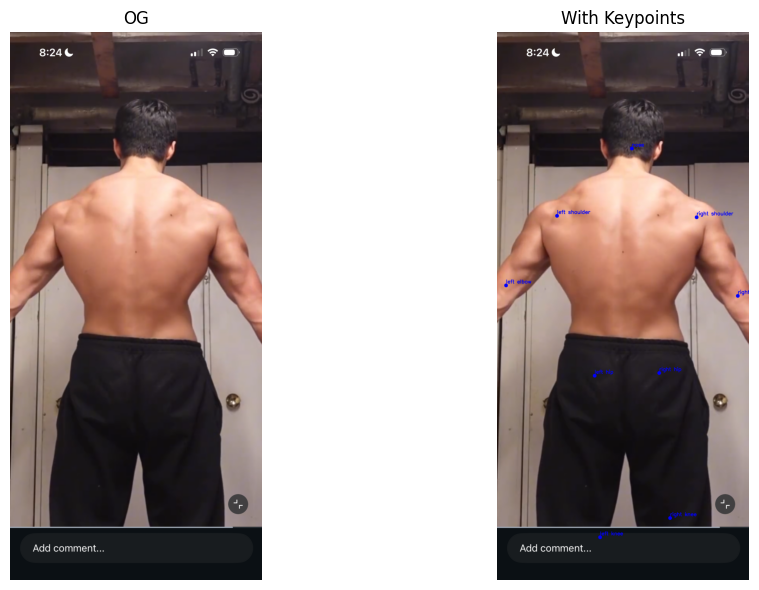

E0000 00:00:1779773363.473566 31431009 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-25T22:40:23.420517-07:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1779773423.487767 31431009 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-25T22:40:23.420517-07:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1779773483.496315 31431009 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not valid for uploading until: 2026-05-25T22:40:23.420517-07:00
=== Source Location Trace: ===
wireless/android/play/playlog/cplusplus/portable_clearcut_uploader.cc:180
E0000 00:00:1779773543.503773 31431009 portable_clearcut_uploader.cc:90] Failed to send to clearcut: FAILED_PRECONDITION: Not v

In [17]:
for img_path in folder_path.glob("*.jpg"):
    detect_pose(img_path)
